<a href="https://colab.research.google.com/github/rxnu/LLM-Project/blob/main/1_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Exploratory Data Analysis

**Goal:**  
- Understand the raw IMDB data.  
- Form and test hypotheses about review length, common phrases, and vocabulary growth.  
- Identify any cleaning needed before modeling.


In [1]:
# 1. Install & import
!pip install -U "datasets<=2.14.5" "fsspec<=2023.6.0"
!pip install --upgrade transformers
!pip install numpy==1.26.0

from datasets import load_dataset, DatasetDict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

## 2. Load the raw IMDB dataset

**To answer:**
1. How many examples in train/test?  
2. What’s the class balance?  
3. Do we need to clean anything (HTML tags, weird characters)?


In [2]:
ds = load_dataset('imdb')
ds

# quick peek
print("Train example 0:", ds["train"][0]["text"][:200], "…\nLabel:", ds["train"][0]["label"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train example 0: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev …
Label: 0


In [3]:
ds['train'].features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['neg', 'pos'], id=None)}

## 3. Dataset sizes

**Hypothesis:** With 25K train / 25K test, we should have enough data to fine‐tune a transformer without overly small splits.

**Observation:**

In [4]:
train_df = pd.DataFrame(ds["train"])
test_df  = pd.DataFrame(ds["test"])
print(f"Train docs: {len(train_df):,}, Test docs: {len(test_df):,}")
print("Class distribution (train):\n", train_df["label"].value_counts(normalize=True))


Train docs: 25,000, Test docs: 25,000
Class distribution (train):
 label
0    0.5
1    0.5
Name: proportion, dtype: float64


## 4. Review length by sentiment

**Hypothesis:** Positive reviews may on average be longer (more detail) than negative ones.  
**Observation:** The median lengths are X vs. Y words, with considerable overlap—length alone is a weak separator.
python
Copy code


<Figure size 600x400 with 0 Axes>

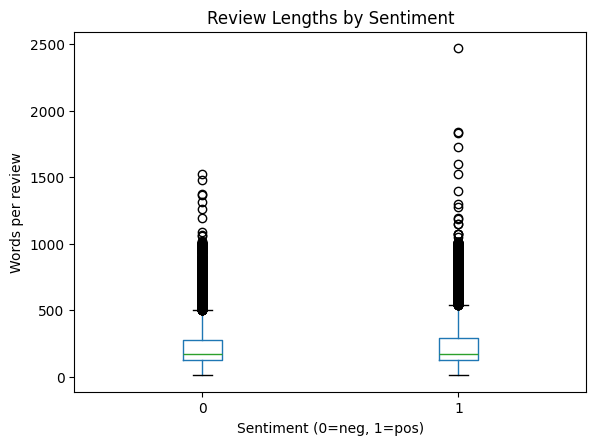

In [5]:
# compute words per review
train_df["word_count"] = train_df["text"].str.split().map(len)

# boxplot
plt.figure(figsize=(6,4))
train_df.boxplot(column="word_count", by="label", grid=False)
plt.suptitle("")  # remove automatic title
plt.xlabel("Sentiment (0=neg, 1=pos)")
plt.ylabel("Words per review")
plt.title("Review Lengths by Sentiment")
plt.show()



## 5. Top 20 bigrams overall

**Why bigrams?** Single words may miss context—e.g. “not good.”  
**Observation:** Many top bigrams are uninformative (“movie was”, “one of”).  We may later remove or filter based on POS or TF-IDF.


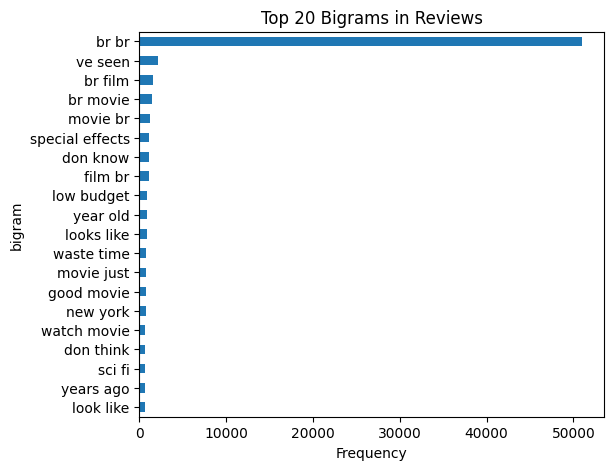

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# common bigrams across all reviews
vec = CountVectorizer(ngram_range=(2,2),
                      stop_words="english",
                      max_features=100)
bag = vec.fit_transform(train_df["text"])
freqs = zip(vec.get_feature_names_out(), bag.sum(axis=0).A1)
top20 = sorted(freqs, key=lambda x: -x[1])[:20]

import pandas as pd
pd.DataFrame(top20, columns=["bigram","count"]).plot.barh(
    x="bigram", y="count", figsize=(6,5), legend=False
)
plt.gca().invert_yaxis()
plt.title("Top 20 Bigrams in Reviews")
plt.xlabel("Frequency")
plt.show()

## 6. Vocabulary growth curve

**Why?** To see if new unique tokens plateau (dataset “saturates”) or keeps growing (lots of noise/typos, rare tokens).  
**Observation:** After ~N reviews, we see M unique tokens—most of your vocabulary is covered early.


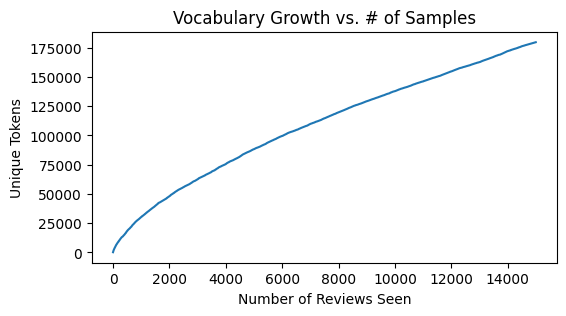

In [7]:
plt.figure(figsize=(6,3))
seen = set()
counts = []
for i, text in enumerate(train_df["text"][:15000], 1):
    seen.update(text.lower().split())
    counts.append(len(seen))

plt.plot(counts, linewidth=1.5)
plt.title("Vocabulary Growth vs. # of Samples")
plt.xlabel("Number of Reviews Seen")
plt.ylabel("Unique Tokens")
plt.show()

## 8. Data Cleaning: HTML & whitespace

**Issue:** reviews include `<br />` tags which will break tokenizers and add noise.  
**Solution:** strip common HTML tags and extra whitespace.


In [8]:
import re

def clean_text(text):
    # remove HTML <br> tags
    clean = re.sub(r"<br\s*/?>", " ", text)
    # collapse multiple spaces/newlines
    clean = re.sub(r"\s+", " ", clean).strip()
    return clean

train_df["cleaned"] = train_df["text"].map(clean_text)
test_df["cleaned"]  = test_df["text"].map(clean_text)

# Quick check
print("Before:", train_df["text"].iloc[0][:100])
print("After: ", train_df["cleaned"].iloc[0][:100])


Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w
After:  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w


### Key EDA takeaways

1. **Length**: broad overlap—word count alone won’t suffice.  
2. **Bigrams**: many uninformative phrases suggest we’ll need TF-IDF or contextual embeddings.  
3. **Vocabulary**: plateaus around X unique tokens by ~10K samples.  
4. **Cleaning**: stripping HTML is essential to avoid spurious tokens.
